<a href="https://colab.research.google.com/github/sahar-mariam/indic-lang-research/blob/main/mt%2Bensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
saharmariam_kannada_sentiment_ksa_path = kagglehub.dataset_download('saharmariam/kannada-sentiment-ksa')

print('Data source import complete.')


In [ ]:
# Install required packages
!pip install -q \
    "transformers>=4.51,<4.58" \
    "accelerate>=0.26" \
    IndicTransToolkit \
    datasets sacrebleu rouge-score bert-score \
    sentencepiece scikit-learn matplotlib seaborn scipy

print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 90.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.3/546.3 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 88.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 6.3 MB/s eta 0:00:00
Done.


In [ ]:
# HuggingFace Login
from huggingface_hub import login
login()

In [ ]:
# Imports and Config
import json, re, unicodedata, warnings, gc, os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    pipeline, TrainingArguments, Trainer,
    EarlyStoppingCallback, DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    cohen_kappa_score, matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
import sacrebleu
from rouge_score import rouge_scorer as rouge_lib

warnings.filterwarnings("ignore")

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# label setup
LABEL_MAP  = {"positive": 0, "negative": 1, "neutral": 2}
ID2LABEL   = {0: "positive", 1: "negative", 2: "neutral"}
NUM_LABELS = 3

# paths
DATA_PATH = "/kaggle/input/datasets/saharmariam/kannada-sentiment-ksa/ksa.jsonl"
OUT       = Path("/kaggle/working/outputs")
OUT.mkdir(exist_ok=True)

# colors used across all figures
COLORS        = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]
CLASS_COLORS  = {"positive": "#55A868", "negative": "#C44E52", "neutral": "#4C72B0"}

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F7F7F7",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"         : 11,
})

print("Config done.")

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Config done.


In [ ]:
# Load Data
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
        if not isinstance(data, list):
            data = [data]
    except json.JSONDecodeError:
        data = [json.loads(l) for l in raw.splitlines() if l.strip()]
    return data

raw_data = load_jsonl(DATA_PATH)
df = pd.DataFrame(raw_data)

# handling both column naming conventions
df = df.rename(columns={"en": "src", "kn": "tgt", "sentiment-label": "label"})

df["label_str"] = df["label"].str.strip().str.lower()
df["label_id"]  = df["label_str"].map(LABEL_MAP)

# dropping rows with unrecognised labels
before = len(df)
df = df.dropna(subset=["label_id"]).reset_index(drop=True)
df["label_id"] = df["label_id"].astype(int)

print(f"Loaded  : {before} rows")
print(f"Clean   : {len(df)} rows  ({before - len(df)} dropped)")
print(f"Labels  : {dict(Counter(df['label_str']))}")
print(df[["src", "tgt", "label_str"]].head(3).to_string())

Loaded  : 962 rows
Clean   : 962 rows  (0 dropped)
Labels  : {'negative': 302, 'positive': 316, 'neutral': 344}
                                                                                          src                                                                                               tgt label_str
0           The food was cold by the time it arrived, and the portion size was disappointing.                                       ಆಹಾರ ತಲುಪುವ ವೇಳೆಗೆ ಚಳಿಯಾಗಿತ್ತು ಮತ್ತು ಪರಿಮಾಣವೂ ನಿರಾಶೆಯಾಯಿತು.  negative
1  The staff were incredibly courteous and made sure we were comfortable throughout our stay.     ಸಿಬ್ಬಂದಿ ಅತಿಯಾದ ಸದಾಚಾರದಿಂದ ನಡೆದುಕೊಂಡರು ಮತ್ತು ನಾವು ಓಡಿರುವ ಅವಧಿಯಲ್ಲೂ ಆರಾಮವಾಗಿರುವಂತೆ ನೋಡಿಕೊಂಡರು.  positive
2                  I ordered a product online, and it arrived on the estimated delivery date.  ನಾನು ಒಂದು ಉತ್ಪನ್ನವನ್ನು ಆನ್‌ಲೈನ್‌ನಲ್ಲಿ ಆರ್ಡರ್ ಮಾಡಿದ್ದು, ಅದು ನಿರೀಕ್ಷಿತ ವಿತರಣಾ ದಿನಾಂಕದಲ್ಲಿ ತಲುಪಿತು.   neutral


In [ ]:
# Preprocessing the data
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200c", "").replace("\u200d", "")
    text = re.sub(r"[\u2018\u2019]", "'", text)
    text = re.sub(r"[\u201c\u201d]", '"', text)
    return re.sub(r"\s+", " ", text).strip()

df["src_clean"] = df["src"].apply(clean_text)
df["tgt_clean"] = df["tgt"].apply(clean_text)

df["src_words"]    = df["src_clean"].str.split().str.len()
df["tgt_words"]    = df["tgt_clean"].str.split().str.len()
df["src_chars"]    = df["src_clean"].str.len()
df["tgt_chars"]    = df["tgt_clean"].str.len()
df["len_ratio"]    = df["tgt_chars"] / (df["src_chars"] + 1e-6)
df["avg_word_len"] = df["src_chars"] / (df["src_words"] + 1e-6)
df["is_short"]     = df["src_words"] <= 2
df["is_long"]      = df["src_words"] > 50

def ttr(text):
    tokens = re.findall(r"\b[a-z]{2,}\b", text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df["ttr"] = df["src_clean"].apply(ttr)

print("Preprocessing done.")
print(f"Short sentences (<=2 words) : {df['is_short'].sum()}")
print(f"Long sentences  (>50 words) : {df['is_long'].sum()}")
print(df[["src_words", "tgt_words", "len_ratio", "ttr"]].describe().round(2).to_string())

Preprocessing done.
Short sentences (<=2 words) : 6
Long sentences  (>50 words) : 1
       src_words  tgt_words  len_ratio     ttr
count     962.00     962.00     962.00  962.00
mean       10.03       7.63       1.06    0.97
std         5.67       3.99       0.26    0.05
min         2.00       2.00       0.29    0.60
25%         7.00       5.00       0.91    1.00
50%         9.00       7.00       1.02    1.00
75%        11.00       9.00       1.17    1.00
max        58.00      43.00       2.93    1.00


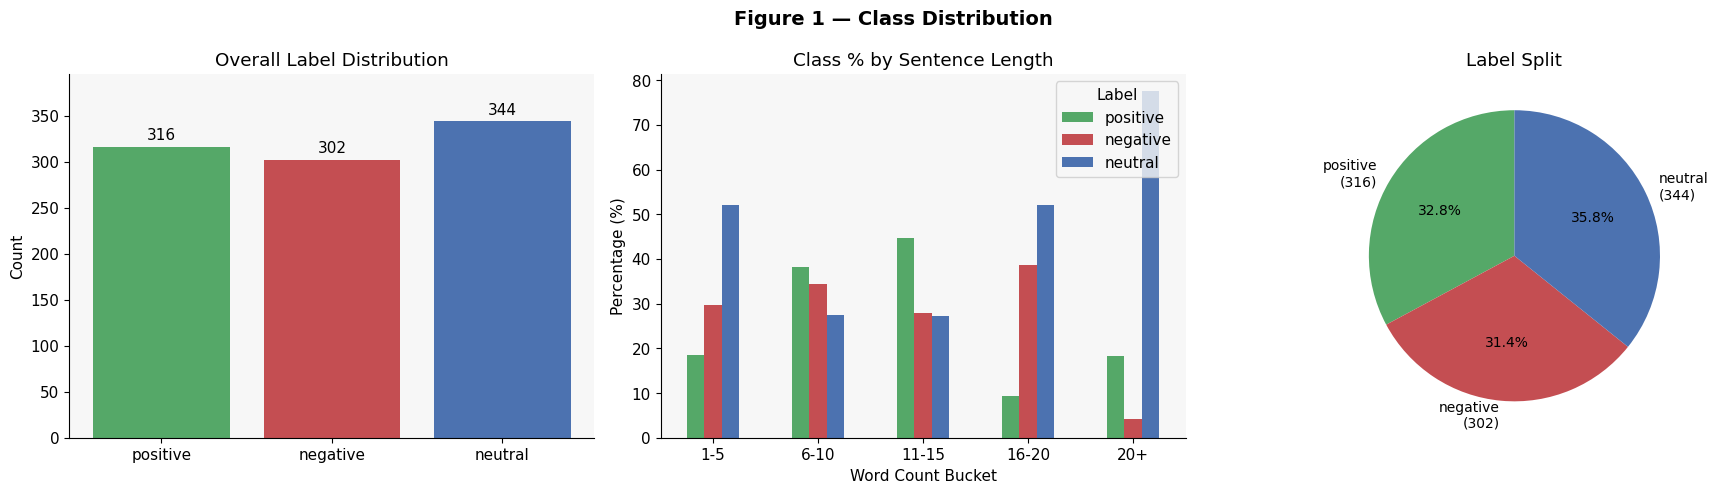

Saved fig1_class_distribution.png


In [ ]:
# EDA
# Figure 1: Class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 1 — Class Distribution", fontsize=14, fontweight="bold")

counts = df["label_str"].value_counts().reindex(["positive","negative","neutral"])

bars = axes[0].bar(counts.index, counts.values,
                   color=[CLASS_COLORS[l] for l in counts.index], edgecolor="none")
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Overall Label Distribution")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.15)

len_bins = pd.cut(df["src_words"], [0,5,10,15,20,999],
                  labels=["1-5","6-10","11-15","16-20","20+"])
df["len_bin"] = len_bins
len_cross = pd.crosstab(df["len_bin"], df["label_str"],
                        normalize="index")[["positive","negative","neutral"]] * 100
len_cross.plot(kind="bar", ax=axes[1],
               color=[CLASS_COLORS[c] for c in ["positive","negative","neutral"]],
               edgecolor="none")
axes[1].set_title("Class % by Sentence Length")
axes[1].set_xlabel("Word Count Bucket")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Label", loc="upper right")

axes[2].pie(counts.values,
            labels=[f"{l}\n({v})" for l, v in zip(counts.index, counts.values)],
            colors=[CLASS_COLORS[l] for l in counts.index],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 10})
axes[2].set_title("Label Split")

plt.tight_layout()
plt.savefig(OUT / "fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_class_distribution.png")

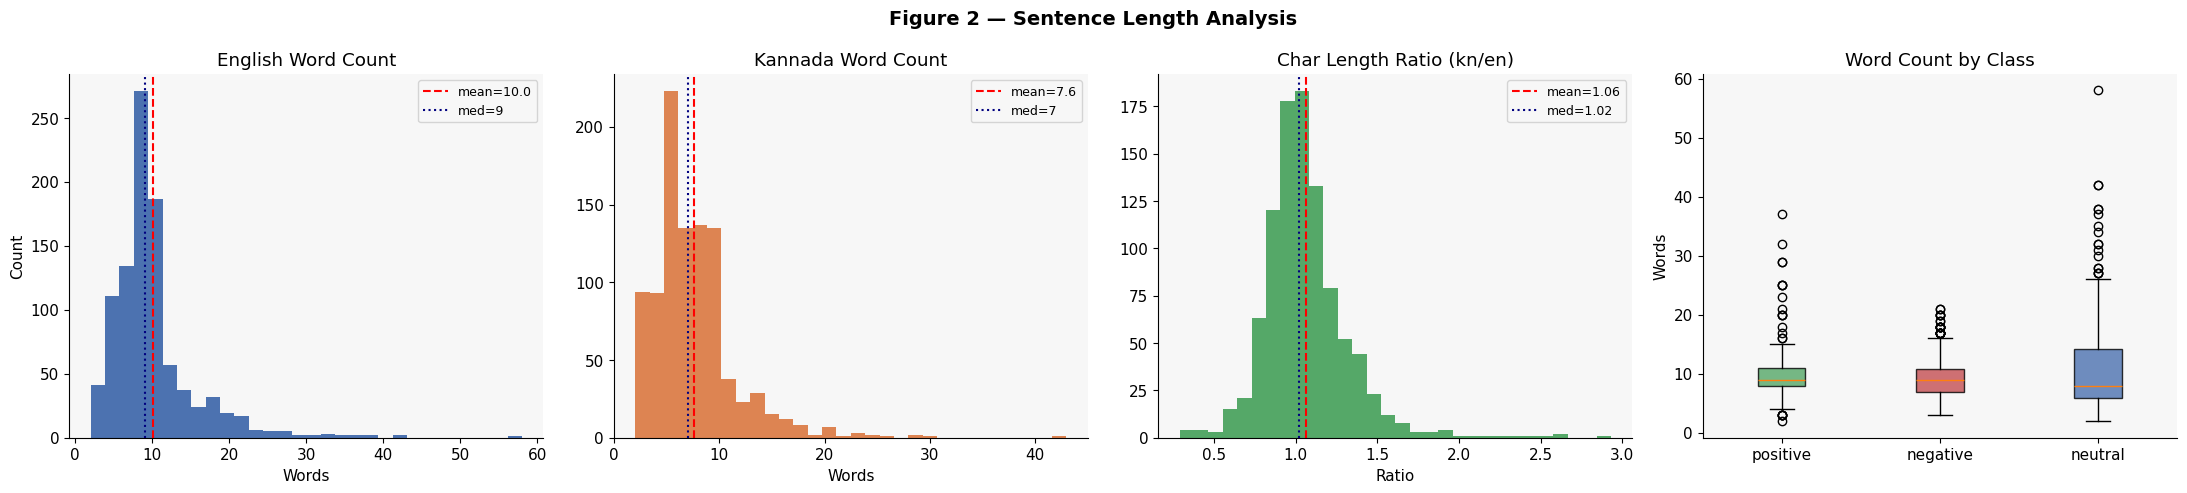

Saved fig2_sentence_lengths.png


In [ ]:
# Figure 2: Sentence length analysis
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Figure 2 — Sentence Length Analysis", fontsize=14, fontweight="bold")

axes[0].hist(df["src_words"], bins=30, color=COLORS[0], edgecolor="none")
axes[0].axvline(df["src_words"].mean(),   color="red",  ls="--", lw=1.5,
                label=f"mean={df['src_words'].mean():.1f}")
axes[0].axvline(df["src_words"].median(), color="navy", ls=":",  lw=1.5,
                label=f"med={df['src_words'].median():.0f}")
axes[0].set_title("English Word Count")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

axes[1].hist(df["tgt_words"], bins=30, color=COLORS[1], edgecolor="none")
axes[1].axvline(df["tgt_words"].mean(),   color="red",  ls="--", lw=1.5,
                label=f"mean={df['tgt_words'].mean():.1f}")
axes[1].axvline(df["tgt_words"].median(), color="navy", ls=":",  lw=1.5,
                label=f"med={df['tgt_words'].median():.0f}")
axes[1].set_title("Kannada Word Count")
axes[1].set_xlabel("Words")
axes[1].legend(fontsize=9)

axes[2].hist(df["len_ratio"].clip(0, 3), bins=30, color=COLORS[2], edgecolor="none")
axes[2].axvline(df["len_ratio"].mean(),   color="red",  ls="--", lw=1.5,
                label=f"mean={df['len_ratio'].mean():.2f}")
axes[2].axvline(df["len_ratio"].median(), color="navy", ls=":",  lw=1.5,
                label=f"med={df['len_ratio'].median():.2f}")
axes[2].set_title("Char Length Ratio (kn/en)")
axes[2].set_xlabel("Ratio")
axes[2].legend(fontsize=9)

box_data = [df.loc[df["label_str"]==l, "src_words"].values
            for l in ["positive","negative","neutral"]]
bp = axes[3].boxplot(box_data, labels=["positive","negative","neutral"],
                     patch_artist=True)
for patch, label in zip(bp["boxes"], ["positive","negative","neutral"]):
    patch.set_facecolor(CLASS_COLORS[label])
    patch.set_alpha(0.8)
axes[3].set_title("Word Count by Class")
axes[3].set_ylabel("Words")

plt.tight_layout()
plt.savefig(OUT / "fig2_sentence_lengths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_sentence_lengths.png")

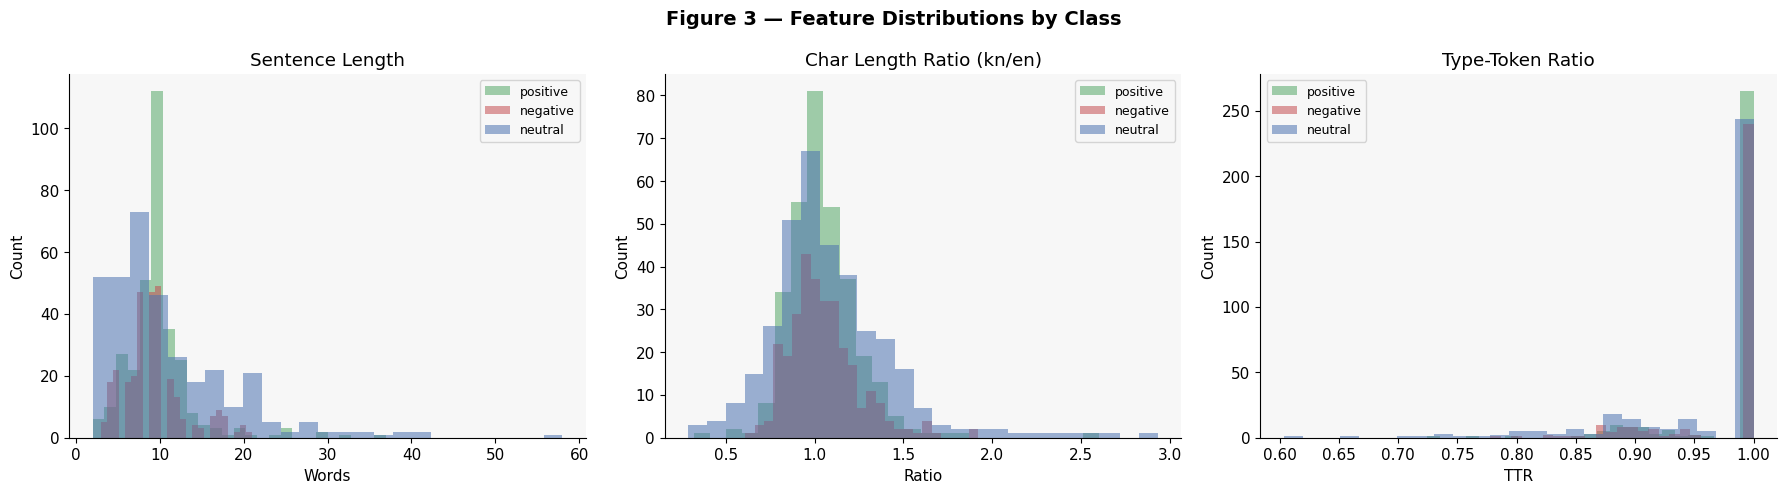

Saved fig3_features_by_class.png


In [ ]:
# Figure 3: Feature distributions by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 3 — Feature Distributions by Class", fontsize=14, fontweight="bold")

for ax, col, title, xlabel in zip(
    axes,
    ["src_words",              "len_ratio",               "ttr"],
    ["Sentence Length",        "Char Length Ratio (kn/en)","Type-Token Ratio"],
    ["Words",                  "Ratio",                    "TTR"]
):
    for label in ["positive", "negative", "neutral"]:
        data = df.loc[df["label_str"] == label, col]
        ax.hist(data, bins=25, alpha=0.55,
                label=label, color=CLASS_COLORS[label], edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "fig3_features_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_features_by_class.png")

In [ ]:
# Translate Kannada → English via IndicTrans2

from IndicTransToolkit import IndicProcessor

IT2_MODEL  = "ai4bharat/indictrans2-indic-en-1B"
SRC_LANG   = "kan_Knda"
TGT_LANG   = "eng_Latn"
BATCH_SIZE = 16

print("Loading IndicTrans2 (1B params) — this takes ~2 min...")
it2_tok = AutoTokenizer.from_pretrained(IT2_MODEL, trust_remote_code=True)
it2_mdl = AutoModelForSeq2SeqLM.from_pretrained(
    IT2_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE).eval()

ip = IndicProcessor(inference=True)
print("Model ready. Starting translation...")

def translate_batch(sentences):
    preprocessed = ip.preprocess_batch(sentences, src_lang=SRC_LANG, tgt_lang=TGT_LANG)
    enc = it2_tok(
        preprocessed, truncation=True, padding="longest",
        max_length=256, return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        out = it2_mdl.generate(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            num_beams=5,
            max_length=256,
            early_stopping=True,
            use_cache=False,
        )
    decoded = it2_tok.batch_decode(out, skip_special_tokens=True)
    return ip.postprocess_batch(decoded, lang=TGT_LANG)

translations = []
for i in range(0, len(df), BATCH_SIZE):
    batch = df["tgt_clean"].iloc[i:i + BATCH_SIZE].tolist()
    translations.extend(translate_batch(batch))
    done = min(i + BATCH_SIZE, len(df))
    if done % 160 == 0 or done == len(df):
        print(f"  {done}/{len(df)}")

df["translated_en"] = translations
print("Translation completed.")

# save backup immediately — don't lose this if session drops
df[["src_clean", "tgt_clean", "translated_en", "label_str", "label_id"]].to_csv(
    "/kaggle/working/translations_backup.csv", index=False
)
print("Backup saved to /kaggle/working/translations_backup.csv")

# sanity check — look at a few translations
print("\nSample translations:")
for i in range(3):
    print(f"  KN : {df['tgt_clean'].iloc[i]}")
    print(f"  EN : {df['translated_en'].iloc[i]}")
    print()

Loading IndicTrans2 (1B params) — this takes ~2 min...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-indic-en-1B:
- tokenization_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


dict.SRC.json: 0.00B [00:00, ?B/s]

...

modeling_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-indic-en-1B:
- modeling_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/4.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

Model ready. Starting translation...
  160/962
  320/962
  480/962
  640/962
  800/962
  960/962
  962/962
Translation completed.
Backup saved to /kaggle/working/translations_backup.csv

Sample translations:
  KN : ಆಹಾರ ತಲುಪುವ ವೇಳೆಗೆ ಚಳಿಯಾಗಿತ್ತು ಮತ್ತು ಪರಿಮಾಣವೂ ನಿರಾಶೆಯಾಯಿತು.
  EN : The food was cold by the time it arrived and the volume was also disappointing.

  KN : ಸಿಬ್ಬಂದಿ ಅತಿಯಾದ ಸದಾಚಾರದಿಂದ ನಡೆದುಕೊಂಡರು ಮತ್ತು ನಾವು ಓಡಿರುವ ಅವಧಿಯಲ್ಲೂ ಆರಾಮವಾಗಿರುವಂತೆ ನೋಡಿಕೊಂಡರು.
  EN : The staff were extremely courteous and made sure we were comfortable during our run.

  KN : ನಾನು ಒಂದು ಉತ್ಪನ್ನವನ್ನು ಆನ್ಲೈನ್ನಲ್ಲಿ ಆರ್ಡರ್ ಮಾಡಿದ್ದು, ಅದು ನಿರೀಕ್ಷಿತ ವಿತರಣಾ ದಿನಾಂಕದಲ್ಲಿ ತಲುಪಿತು.
  EN : I ordered a product online that arrived on the expected delivery date.



Corpus BLEU : 32.61
ROUGE-1     : 0.6488
ROUGE-2     : 0.4221
ROUGE-L     : 0.6071


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore   : 0.9548  (first 500 samples)


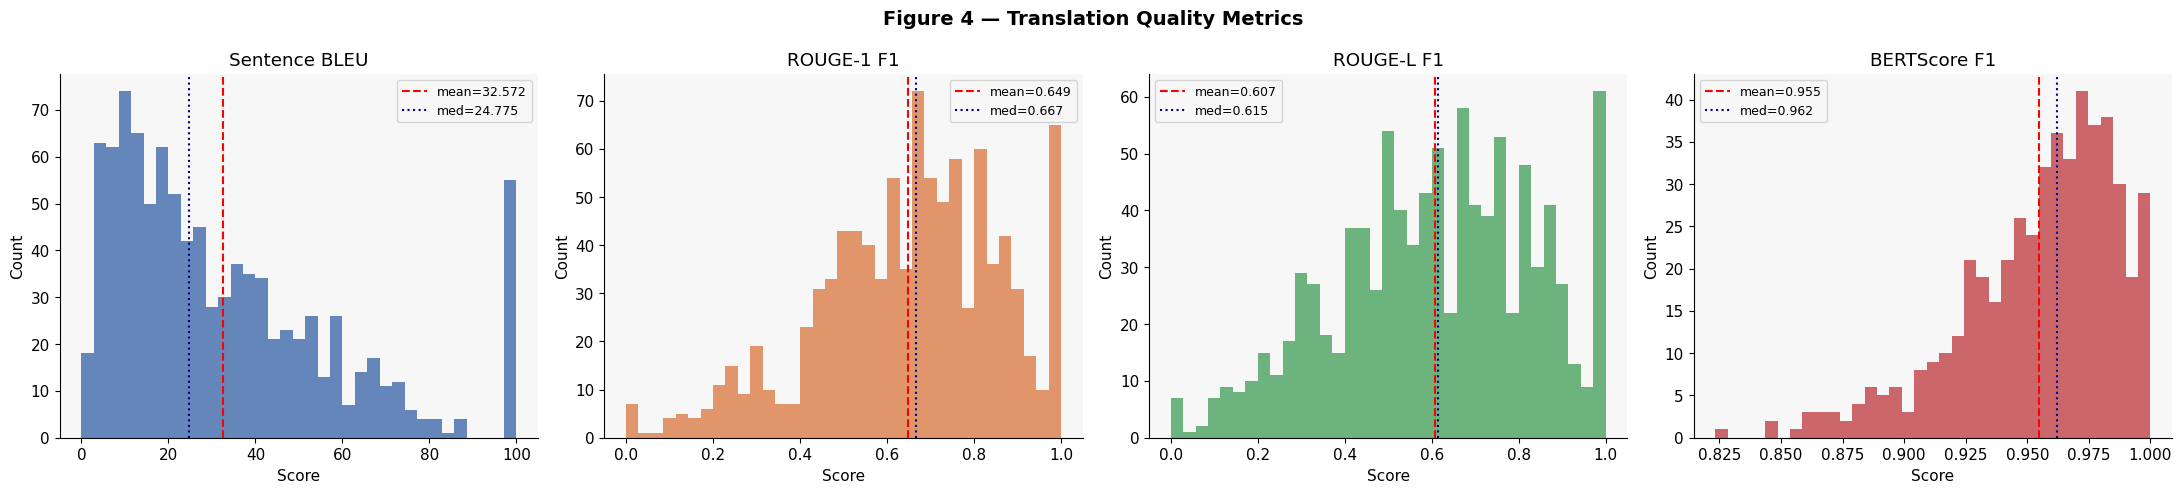

Saved fig4_translation_quality.png


In [ ]:
# Translation Quality Metrics

hyps = df["translated_en"].tolist()
refs = df["src_clean"].tolist()

# Corpus BLEU
corpus_bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
print(f"Corpus BLEU : {corpus_bleu:.2f}")

# per-sentence BLEU + ROUGE
rscorer = rouge_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
sent_bleu, r1_scores, r2_scores, rL_scores = [], [], [], []

for h, r in zip(hyps, refs):
    sent_bleu.append(sacrebleu.sentence_bleu(h, [r]).score)
    rs = rscorer.score(r, h)
    r1_scores.append(rs["rouge1"].fmeasure)
    r2_scores.append(rs["rouge2"].fmeasure)
    rL_scores.append(rs["rougeL"].fmeasure)

df["sent_bleu"] = sent_bleu
df["rouge1"]    = r1_scores
df["rouge2"]    = r2_scores
df["rougeL"]    = rL_scores

print(f"ROUGE-1     : {np.mean(r1_scores):.4f}")
print(f"ROUGE-2     : {np.mean(r2_scores):.4f}")
print(f"ROUGE-L     : {np.mean(rL_scores):.4f}")

# BERTScore on first 500 samples
try:
    from bert_score import score as bs_fn
    N = min(500, len(df))
    _, _, F1 = bs_fn(hyps[:N], refs[:N], lang="en", verbose=False)
    mean_bs = F1.mean().item()
    df["bertscore"] = list(F1.numpy()) + [np.nan] * (len(df) - N)
    print(f"BERTScore   : {mean_bs:.4f}  (first {N} samples)")
except Exception as e:
    print(f"BERTScore skipped: {e}")
    df["bertscore"] = np.nan
    mean_bs = np.nan

# Figure 4 — Translation quality distributions
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Figure 4 — Translation Quality Metrics", fontsize=14, fontweight="bold")

for ax, col, title, color in zip(
    axes,
    ["sent_bleu", "rouge1",    "rougeL",    "bertscore"],
    ["Sentence BLEU", "ROUGE-1 F1", "ROUGE-L F1", "BERTScore F1"],
    COLORS
):
    data = df[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax.set_title(title)
        continue
    ax.hist(data, bins=35, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(data.mean(),   color="red",  ls="--", lw=1.5,
               label=f"mean={data.mean():.3f}")
    ax.axvline(data.median(), color="navy", ls=":",  lw=1.5,
               label=f"med={data.median():.3f}")
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "fig4_translation_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig4_translation_quality.png")

In [ ]:
# Free GPU memory before training

del it2_mdl, it2_tok, ip
torch.cuda.empty_cache()
gc.collect()

print("GPU memory freed.")
print(f"Memory allocated : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Memory reserved  : {torch.cuda.memory_reserved()  / 1e9:.2f} GB")

GPU memory freed.
Memory allocated : 0.01 GB
Memory reserved  : 0.02 GB


In [ ]:
# Train/Test Split

clf = df[["translated_en", "label_id"]].dropna().copy()
clf = clf[clf["translated_en"].str.strip().str.len() > 5].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    clf["translated_en"].tolist(),
    clf["label_id"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=clf["label_id"].tolist()
)

print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")
print(f"Train dist : {dict(Counter(y_train))}")
print(f"Test  dist : {dict(Counter(y_test))}")

Train : 769
Test  : 193
Train dist : {2: 275, 0: 253, 1: 241}
Test  dist : {1: 61, 0: 63, 2: 69}


In [ ]:
# ── CELL 11: Fine-tune Helper Function ───────────────────────

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"  : accuracy_score(labels, preds),
        "f1"        : f1_score(labels, preds, average="weighted", zero_division=0),
        "precision" : precision_score(labels, preds, average="weighted", zero_division=0),
        "recall"    : recall_score(labels, preds, average="weighted", zero_division=0),
    }

def finetune(model_name, short_name, max_len=128, epochs=4,
             bs_train=16, bs_eval=32, lr=2e-5, wd=0.01):
    print(f"\n{'─'*50}")
    print(f"Training : {short_name}")
    print(f"{'─'*50}")

    tok   = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        ignore_mismatched_sizes=True
    )

    def make_dataset(texts, labels):
        enc = tok(texts, truncation=True, padding=True, max_length=max_len)
        enc["labels"] = labels
        return Dataset.from_dict(enc)

    train_ds = make_dataset(X_train, y_train)
    test_ds  = make_dataset(X_test,  y_test)

    args = TrainingArguments(
        output_dir                  = "/kaggle/working/tmp_trainer",
        num_train_epochs            = epochs,
        learning_rate               = lr,
        weight_decay                = wd,
        per_device_train_batch_size = bs_train,
        per_device_eval_batch_size  = bs_eval,
        eval_strategy               = "epoch",
        save_strategy               = "no",
        load_best_model_at_end      = False,
        fp16                        = (DEVICE == "cuda"),
        seed                        = SEED,
        logging_steps               = 20,
        report_to                   = "none",
        disable_tqdm                = False,
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = test_ds,
        compute_metrics = compute_metrics,
        data_collator   = DataCollatorWithPadding(tok),
    )
    trainer.train()

    # predict on test set
    enc_test = tok(X_test, truncation=True, padding=True,
                   max_length=max_len, return_tensors="pt")
    model.eval()
    with torch.no_grad():
        logits = model(**{k: v.to(DEVICE) for k, v in enc_test.items()}).logits.cpu()

    probs = torch.softmax(logits.float(), dim=-1).numpy()
    preds = np.argmax(probs, axis=1)

    y_bin = label_binarize(y_test, classes=[0, 1, 2])
    try:
        auc = roc_auc_score(y_bin, probs, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan

    result = {
        "short_name" : short_name,
        "accuracy"   : accuracy_score(y_test, preds),
        "f1"         : f1_score(y_test, preds, average="weighted", zero_division=0),
        "precision"  : precision_score(y_test, preds, average="weighted", zero_division=0),
        "recall"     : recall_score(y_test, preds, average="weighted", zero_division=0),
        "kappa"      : cohen_kappa_score(y_test, preds),
        "mcc"        : matthews_corrcoef(y_test, preds),
        "auc_roc"    : auc,
        "preds"      : preds,
        "probs"      : probs,
        "report"     : classification_report(
                           y_test, preds,
                           target_names=["positive","negative","neutral"],
                           output_dict=True
                       ),
    }

    print(f"  Acc={result['accuracy']:.4f}  F1={result['f1']:.4f}  AUC={result['auc_roc']:.4f}")

    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()
    return result

print("Cell run confirmation.")

Cell run confirmation.


In [ ]:
#  Clean up old checkpoints
import shutil

for name in ["MuRIL", "mBERT", "XLM-R", "IndicBERT", "DistilBERT"]:
    ckpt_path = OUT / f"ckpt_{name}"
    if ckpt_path.exists():
        shutil.rmtree(ckpt_path)
        print(f"Deleted {ckpt_path}")

tmp_path = Path("/kaggle/working/tmp_trainer")
if tmp_path.exists():
    shutil.rmtree(tmp_path)
    print("Deleted tmp_trainer")

total, used, free = shutil.disk_usage("/kaggle/working")
print(f"\nFree disk : {free / 1e9:.1f} GB")
print(f"Used disk : {used / 1e9:.1f} GB")

Deleted /kaggle/working/outputs/ckpt_MuRIL
Deleted /kaggle/working/outputs/ckpt_mBERT
Deleted /kaggle/working/outputs/ckpt_XLM-R

Free disk : 20.9 GB
Used disk : 0.0 GB


In [ ]:
# Initialize results dict
all_res = {}

# Train MuRIL
all_res["MuRIL"] = finetune("google/muril-base-cased", "MuRIL")
print(f"Done. F1={all_res['MuRIL']['f1']:.4f}")
print(f"Trained so far: {list(all_res.keys())}")


──────────────────────────────────────────────────
Training : MuRIL
──────────────────────────────────────────────────


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.098600,1.097607,0.419689,0.310520,0.778777,0.419689
2,1.096300,1.074216,0.756477,0.720832,0.824652,0.756477
3,1.077800,1.036644,0.772021,0.742815,0.832762,0.772021
4,1.037400,1.026341,0.792746,0.772540,0.834480,0.792746


  Acc=0.7927  F1=0.7725  AUC=0.9333
Done. F1=0.7725
Trained so far: ['MuRIL']


In [ ]:
# Training mBERT
all_res["mBERT"] = finetune("bert-base-multilingual-cased", "mBERT")
print(f"Done. F1={all_res['mBERT']['f1']:.4f}")
print(f"Trained so far: {list(all_res.keys())}")


──────────────────────────────────────────────────
Training : mBERT
──────────────────────────────────────────────────


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.004900,0.804756,0.704663,0.699800,0.718580,0.704663
2,0.706000,0.568323,0.803109,0.800644,0.809893,0.803109
3,0.482500,0.541543,0.818653,0.816382,0.827182,0.818653
4,0.325700,0.499361,0.823834,0.821518,0.833112,0.823834


  Acc=0.8238  F1=0.8215  AUC=0.9400
Done. F1=0.8215
Trained so far: ['MuRIL', 'mBERT']


In [ ]:
# Training XLM-R
all_res["XLM-R"] = finetune("xlm-roberta-base", "XLM-R")
print(f"Done. F1={all_res['XLM-R']['f1']:.4f}")
print(f"Trained so far: {list(all_res.keys())}")


──────────────────────────────────────────────────
Training : XLM-R
──────────────────────────────────────────────────


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.092400,0.871280,0.792746,0.792767,0.793212,0.792746
2,0.914200,0.586581,0.740933,0.711616,0.778895,0.740933
3,0.689000,0.469638,0.834197,0.828651,0.838496,0.834197
4,0.470300,0.454885,0.829016,0.823637,0.838219,0.829016


  Acc=0.8290  F1=0.8236  AUC=0.9570
Done. F1=0.8236
Trained so far: ['MuRIL', 'mBERT', 'XLM-R']


In [ ]:
# Training IndicBERT
try:
    all_res["IndicBERT"] = finetune(
        "neuralspace-reverie/indic-transformers-kn-bert", "IndicBERT"
    )
except OSError:
    print("First option failed, trying fallback...")
    try:
        all_res["IndicBERT"] = finetune(
            "l3cube-pune/kannada-bert", "IndicBERT"
        )
    except OSError:
        print("Second option failed, using sandalwood...")
        all_res["IndicBERT"] = finetune(
            "ai4bharat/indic-bert-v2", "IndicBERT"
        )

print(f"Done. F1={all_res['IndicBERT']['f1']:.4f}")
print(f"Trained so far: {list(all_res.keys())}")


──────────────────────────────────────────────────
Training : IndicBERT
──────────────────────────────────────────────────
First option failed, trying fallback...

──────────────────────────────────────────────────
Training : IndicBERT
──────────────────────────────────────────────────


tokenizer_config.json:   0%|          | 0.00/452 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at l3cube-pune/kannada-bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.098500,1.097319,0.326425,0.160662,0.106553,0.326425
2,1.097300,1.080897,0.668394,0.618568,0.708035,0.668394
3,1.082900,1.046751,0.699482,0.652448,0.735467,0.699482
4,1.045600,1.034315,0.725389,0.690284,0.767676,0.725389


  Acc=0.7254  F1=0.6903  AUC=0.9304
Done. F1=0.6903
Trained so far: ['MuRIL', 'mBERT', 'XLM-R', 'IndicBERT']


In [ ]:
# Training DistilBERT
all_res["DistilBERT"] = finetune("distilbert-base-multilingual-cased", "DistilBERT")
print(f"Done. F1={all_res['DistilBERT']['f1']:.4f}")
print(f"Trained so far: {list(all_res.keys())}")


──────────────────────────────────────────────────
Training : DistilBERT
──────────────────────────────────────────────────


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.065500,0.950196,0.668394,0.663126,0.684067,0.668394
2,0.879800,0.707987,0.735751,0.731921,0.746608,0.735751
3,0.661500,0.607080,0.766839,0.765325,0.766994,0.766839
4,0.491000,0.596495,0.761658,0.759549,0.763901,0.761658


  Acc=0.7617  F1=0.7595  AUC=0.9174
Done. F1=0.7595
Trained so far: ['MuRIL', 'mBERT', 'XLM-R', 'IndicBERT', 'DistilBERT']


In [ ]:
# Verifying trained data for all 5 trained models
expected = {"MuRIL", "mBERT", "XLM-R", "IndicBERT", "DistilBERT"}
missing  = expected - set(all_res.keys())

if missing:
    print(f"WARNING: Missing — {missing}")
    print("Rerun those cells before proceeding.")
else:
    print("All 5 models trained.\n")
    print(f"{'Model':<12} {'Acc':>8} {'F1':>8} {'AUC':>8}")
    print("─" * 40)
    for name, r in all_res.items():
        print(f"{name:<12} {r['accuracy']:>8.4f} {r['f1']:>8.4f} {r['auc_roc']:>8.4f}")

All 5 models trained.

Model             Acc       F1      AUC
────────────────────────────────────────
MuRIL          0.7927   0.7725   0.9333
mBERT          0.8238   0.8215   0.9400
XLM-R          0.8290   0.8236   0.9570
IndicBERT      0.7254   0.6903   0.9304
DistilBERT     0.7617   0.7595   0.9174


In [ ]:
# Ensemble Methods

all_probs = np.stack([r["probs"] for r in all_res.values()])   # (5, N, 3)
all_preds = np.stack([r["preds"] for r in all_res.values()])   # (5, N)
f1_weights = np.array([r["f1"] for r in all_res.values()])
y_bin = label_binarize(y_test, classes=[0, 1, 2])

# soft voting — average probabilities
soft_probs = all_probs.mean(axis=0)
soft_preds = np.argmax(soft_probs, axis=1)

# hard voting — majority vote
hard_preds = np.apply_along_axis(
    lambda x: np.bincount(x, minlength=3).argmax(), 0, all_preds
)

# weighted voting — weight each model by its F1
w = f1_weights / f1_weights.sum()
weighted_probs = (all_probs * w[:, None, None]).sum(axis=0)
weighted_preds = np.argmax(weighted_probs, axis=1)

def ens_metrics(preds, probs, name):
    try:
        auc = roc_auc_score(y_bin, probs, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan
    return {
        "short_name" : name,
        "accuracy"   : accuracy_score(y_test, preds),
        "f1"         : f1_score(y_test, preds, average="weighted", zero_division=0),
        "precision"  : precision_score(y_test, preds, average="weighted", zero_division=0),
        "recall"     : recall_score(y_test, preds, average="weighted", zero_division=0),
        "kappa"      : cohen_kappa_score(y_test, preds),
        "mcc"        : matthews_corrcoef(y_test, preds),
        "auc_roc"    : auc,
        "preds"      : preds,
        "probs"      : probs,
        "report"     : classification_report(
                           y_test, preds,
                           target_names=["positive","negative","neutral"],
                           output_dict=True
                       ),
    }

ens_res = {
    "Soft Voting"    : ens_metrics(soft_preds,    soft_probs,    "Soft Voting"),
    "Hard Voting"    : ens_metrics(hard_preds,     soft_probs,    "Hard Voting"),
    "Weighted Voting": ens_metrics(weighted_preds, weighted_probs,"Weighted Voting"),
}

print(f"{'Method':<20} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print("─" * 48)
for name, r in ens_res.items():
    print(f"{name:<20} {r['accuracy']:>8.4f} {r['f1']:>8.4f} {r['auc_roc']:>8.4f}")

Method                    Acc       F1      AUC
────────────────────────────────────────────────
Soft Voting            0.8342   0.8304   0.9596
Hard Voting            0.8290   0.8189   0.9596
Weighted Voting        0.8342   0.8304   0.9598


In [ ]:
# Results Table

combined = {**all_res, **ens_res}

rows = []
for r in combined.values():
    rows.append({
        "Model"     : r["short_name"],
        "Accuracy"  : round(r["accuracy"],  4),
        "F1"        : round(r["f1"],        4),
        "Precision" : round(r["precision"], 4),
        "Recall"    : round(r["recall"],    4),
        "Kappa"     : round(r["kappa"],     4),
        "MCC"       : round(r["mcc"],       4),
        "AUC-ROC"   : round(r["auc_roc"],   4),
    })

results_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

print("── Results (sorted by F1) ───────────────────────────────")
print(results_df.to_string(index=False))

results_df.to_csv(OUT / "results_all_models.csv", index=False)
print("\nSaved results_all_models.csv")

── Results (sorted by F1) ───────────────────────────────
          Model  Accuracy     F1  Precision  Recall  Kappa    MCC  AUC-ROC
Weighted Voting    0.8342 0.8304     0.8455  0.8342 0.7523 0.7602   0.9598
    Soft Voting    0.8342 0.8304     0.8455  0.8342 0.7523 0.7602   0.9596
          XLM-R    0.8290 0.8236     0.8382  0.8290 0.7446 0.7528   0.9570
          mBERT    0.8238 0.8215     0.8331  0.8238 0.7366 0.7423   0.9400
    Hard Voting    0.8290 0.8189     0.8567  0.8290 0.7451 0.7635   0.9596
          MuRIL    0.7927 0.7725     0.8345  0.7927 0.6917 0.7207   0.9333
     DistilBERT    0.7617 0.7595     0.7639  0.7617 0.6432 0.6459   0.9174
      IndicBERT    0.7254 0.6903     0.7677  0.7254 0.5923 0.6282   0.9304

Saved results_all_models.csv


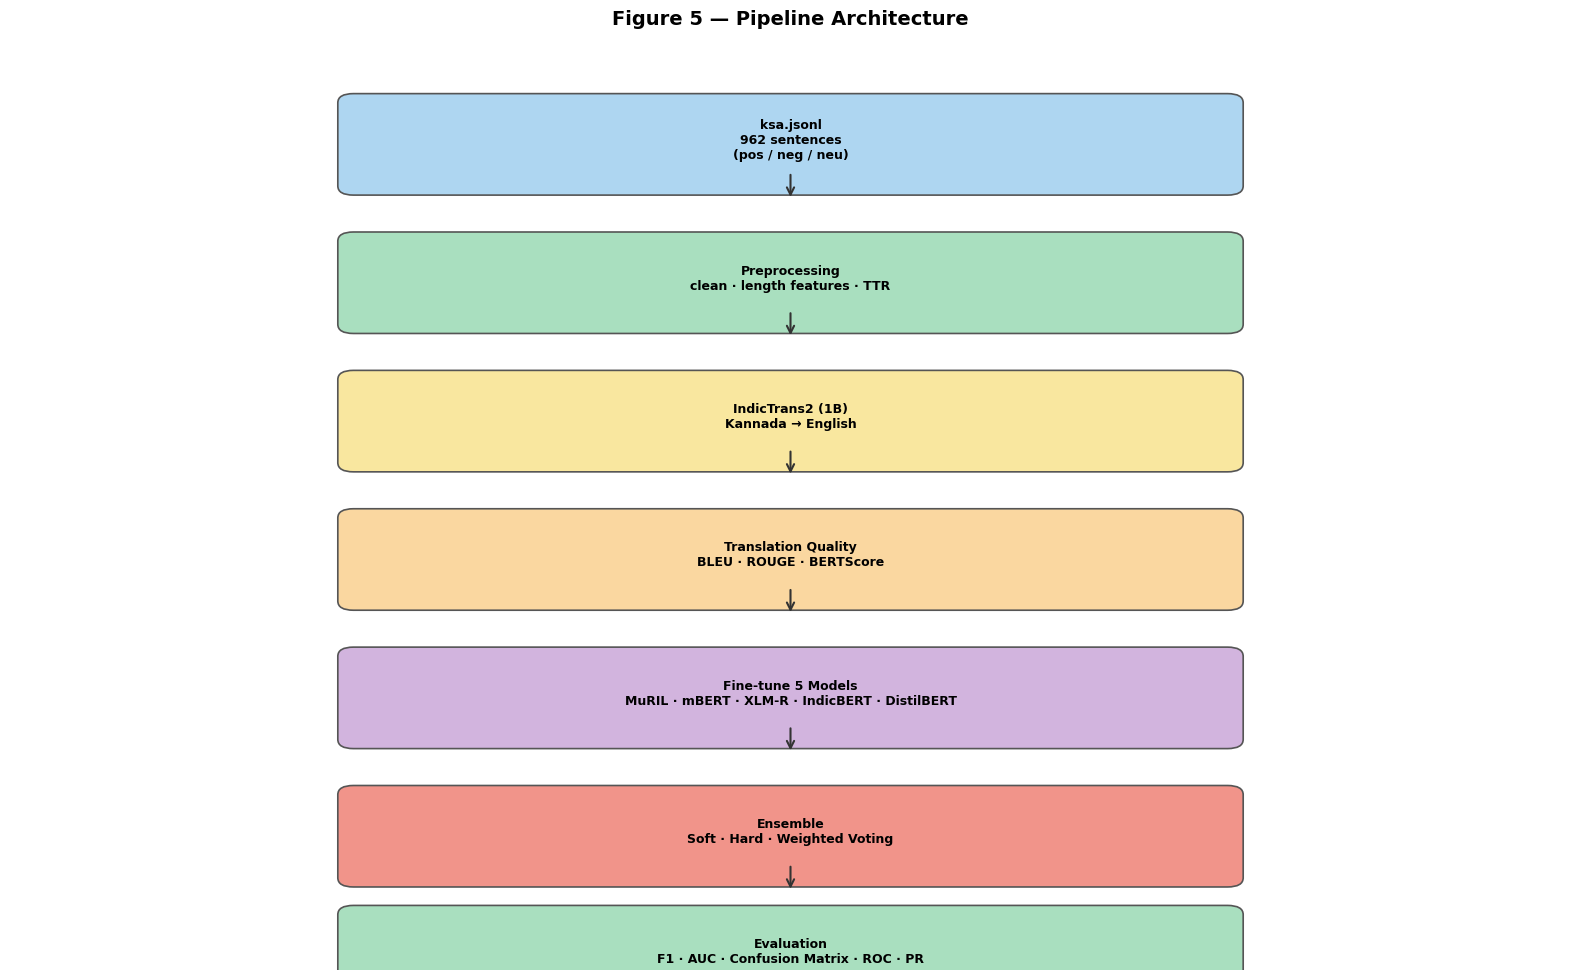

Saved fig5_pipeline.png


In [ ]:
# All Relevant Figures
import matplotlib
import matplotlib.patches

# increase font sizes for all figures
plt.rcParams.update({
    "font.size"        : 13,
    "axes.titlesize"   : 14,
    "axes.labelsize"   : 13,
    "xtick.labelsize"  : 11,
    "ytick.labelsize"  : 11,
    "legend.fontsize"  : 11,
    "figure.titlesize" : 15,
})

model_names = list(all_res.keys())
class_names = ["positive", "negative", "neutral"]

# Pipeline architecture diagram
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor("white")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("white")
fig.suptitle("Figure 5 — Pipeline Architecture", fontsize=14, fontweight="bold")

boxes = [
    (5.0, 9.0, "ksa.jsonl\n962 sentences\n(pos / neg / neu)",       "#AED6F1"),
    (5.0, 7.5, "Preprocessing\nclean · length features · TTR",       "#A9DFBF"),
    (5.0, 6.0, "IndicTrans2 (1B)\nKannada → English",                "#F9E79F"),
    (5.0, 4.5, "Translation Quality\nBLEU · ROUGE · BERTScore",      "#FAD7A0"),
    (5.0, 3.0, "Fine-tune 5 Models\nMuRIL · mBERT · XLM-R · IndicBERT · DistilBERT", "#D2B4DE"),
    (5.0, 1.5, "Ensemble\nSoft · Hard · Weighted Voting",            "#F1948A"),
    (5.0, 0.2, "Evaluation\nF1 · AUC · Confusion Matrix · ROC · PR", "#A9DFBF"),
]

for x, y, text, color in boxes:
    ax.add_patch(matplotlib.patches.FancyBboxPatch(
        (x - 2.8, y - 0.5), 5.6, 0.9,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor="#555555", linewidth=1.2
    ))
    ax.text(x, y, text, ha="center", va="center", fontsize=9, fontweight="bold")

# arrows between boxes
arrow_y = [8.5, 7.0, 5.5, 4.0, 2.5, 1.0]
for y in arrow_y:
    ax.annotate("", xy=(5.0, y - 0.15), xytext=(5.0, y + 0.15),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.5))

plt.tight_layout()
plt.savefig(OUT / "fig5_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig5_pipeline.png")

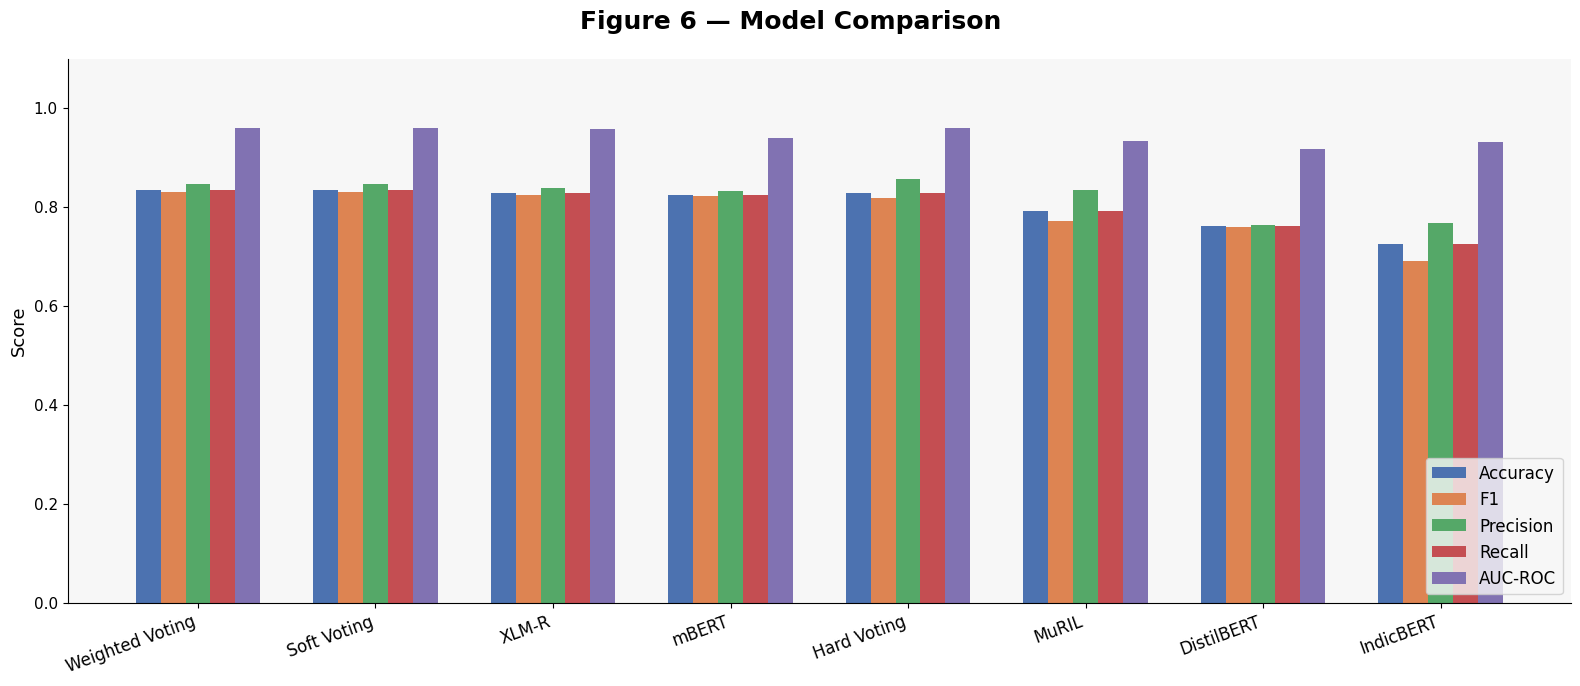

Saved fig6_model_comparison.png


In [ ]:
# Model Comparison Bar Chart
metrics_show = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle("Figure 6 — Model Comparison", fontsize=18, fontweight="bold")

x     = np.arange(len(results_df))
width = 0.14
for i, m in enumerate(metrics_show):
    ax.bar(x + i * width, results_df[m], width,
           label=m, color=COLORS[i], edgecolor="none")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df["Model"], rotation=20, ha="right", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=13)
ax.tick_params(axis="y", labelsize=11)
ax.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.savefig(OUT / "fig6_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig6_model_comparison.png")

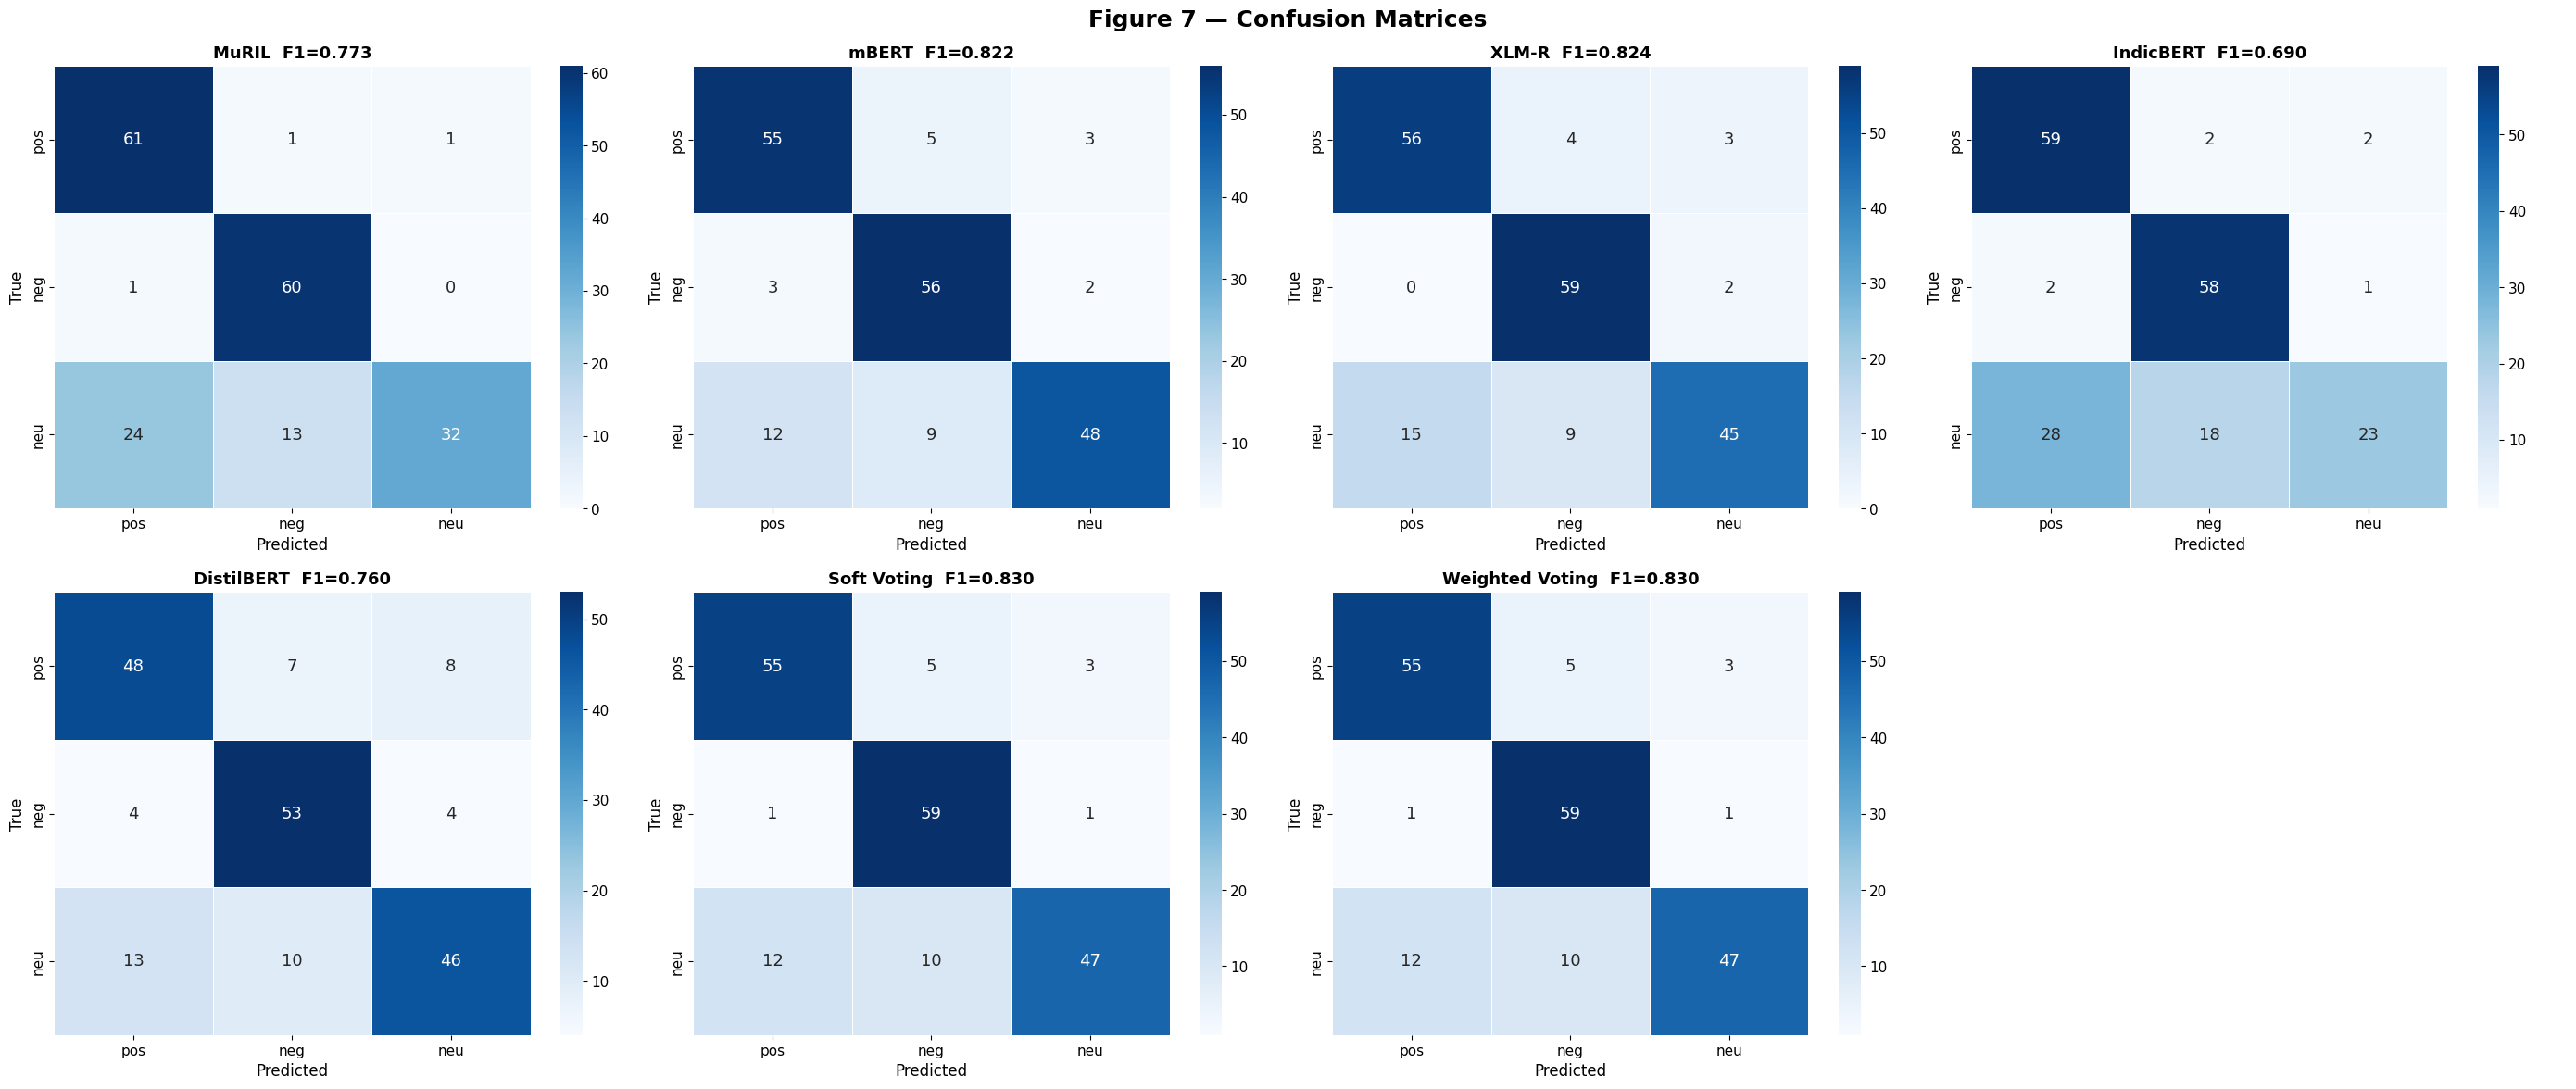

Saved fig7_confusion_matrices.png


In [ ]:
# Confusion Matrices
show_models = list(all_res.items()) + [
    ("Soft Voting",     ens_res["Soft Voting"]),
    ("Weighted Voting", ens_res["Weighted Voting"]),
]

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle("Figure 7 — Confusion Matrices", fontsize=18, fontweight="bold")

for idx, (name, r) in enumerate(show_models):
    ax = axes.flatten()[idx]
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["pos","neg","neu"],
                yticklabels=["pos","neg","neu"],
                ax=ax, linewidths=0.4,
                annot_kws={"size": 13})
    ax.set_title(f"{r['short_name']}  F1={r['f1']:.3f}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)

axes.flatten()[-1].axis("off")

plt.tight_layout()
plt.savefig(OUT / "fig7_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig7_confusion_matrices.png")

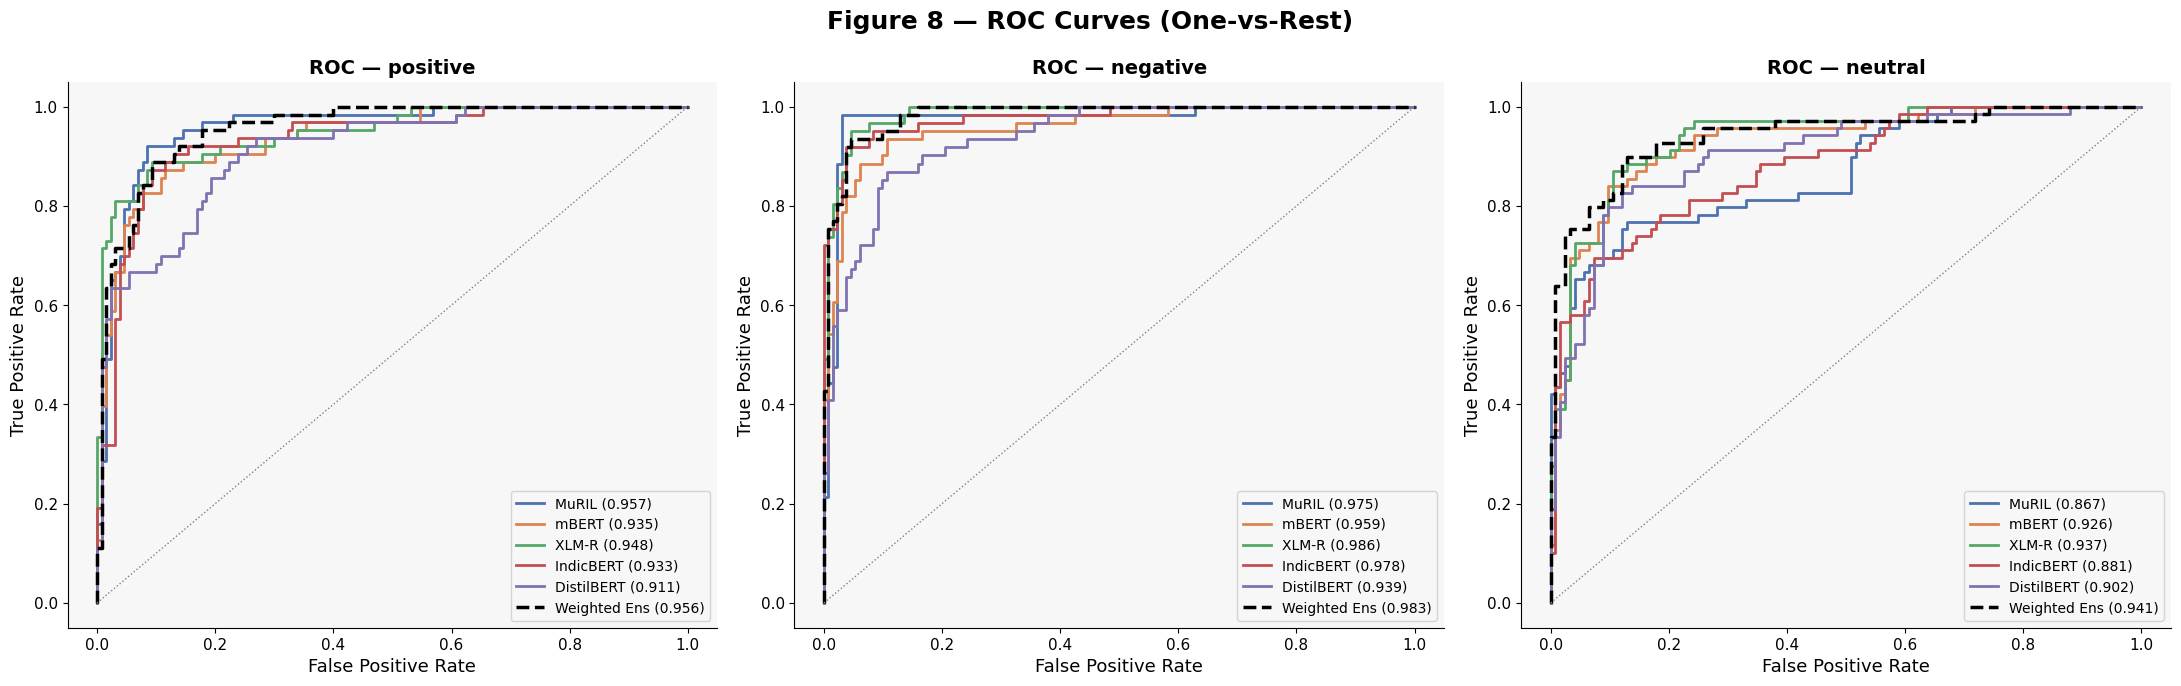

Saved fig8_roc_curves.png


In [ ]:
# ROC Curves (One-vs-Rest)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Figure 8 — ROC Curves (One-vs-Rest)", fontsize=18, fontweight="bold")

best_ens = ens_res["Weighted Voting"]

for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_names)):
    for i, (name, r) in enumerate(all_res.items()):
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], r["probs"][:, cls_idx])
        auc = roc_auc_score(y_bin[:, cls_idx], r["probs"][:, cls_idx])
        ax.plot(fpr, tpr, color=COLORS[i], lw=2.0,
                label=f"{r['short_name']} ({auc:.3f})")
    fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], best_ens["probs"][:, cls_idx])
    auc = roc_auc_score(y_bin[:, cls_idx], best_ens["probs"][:, cls_idx])
    ax.plot(fpr, tpr, "k--", lw=2.5,
            label=f"Weighted Ens ({auc:.3f})")
    ax.plot([0,1],[0,1], ":", color="gray", lw=1)
    ax.set_title(f"ROC — {cls_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig(OUT / "fig8_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig8_roc_curves.png")

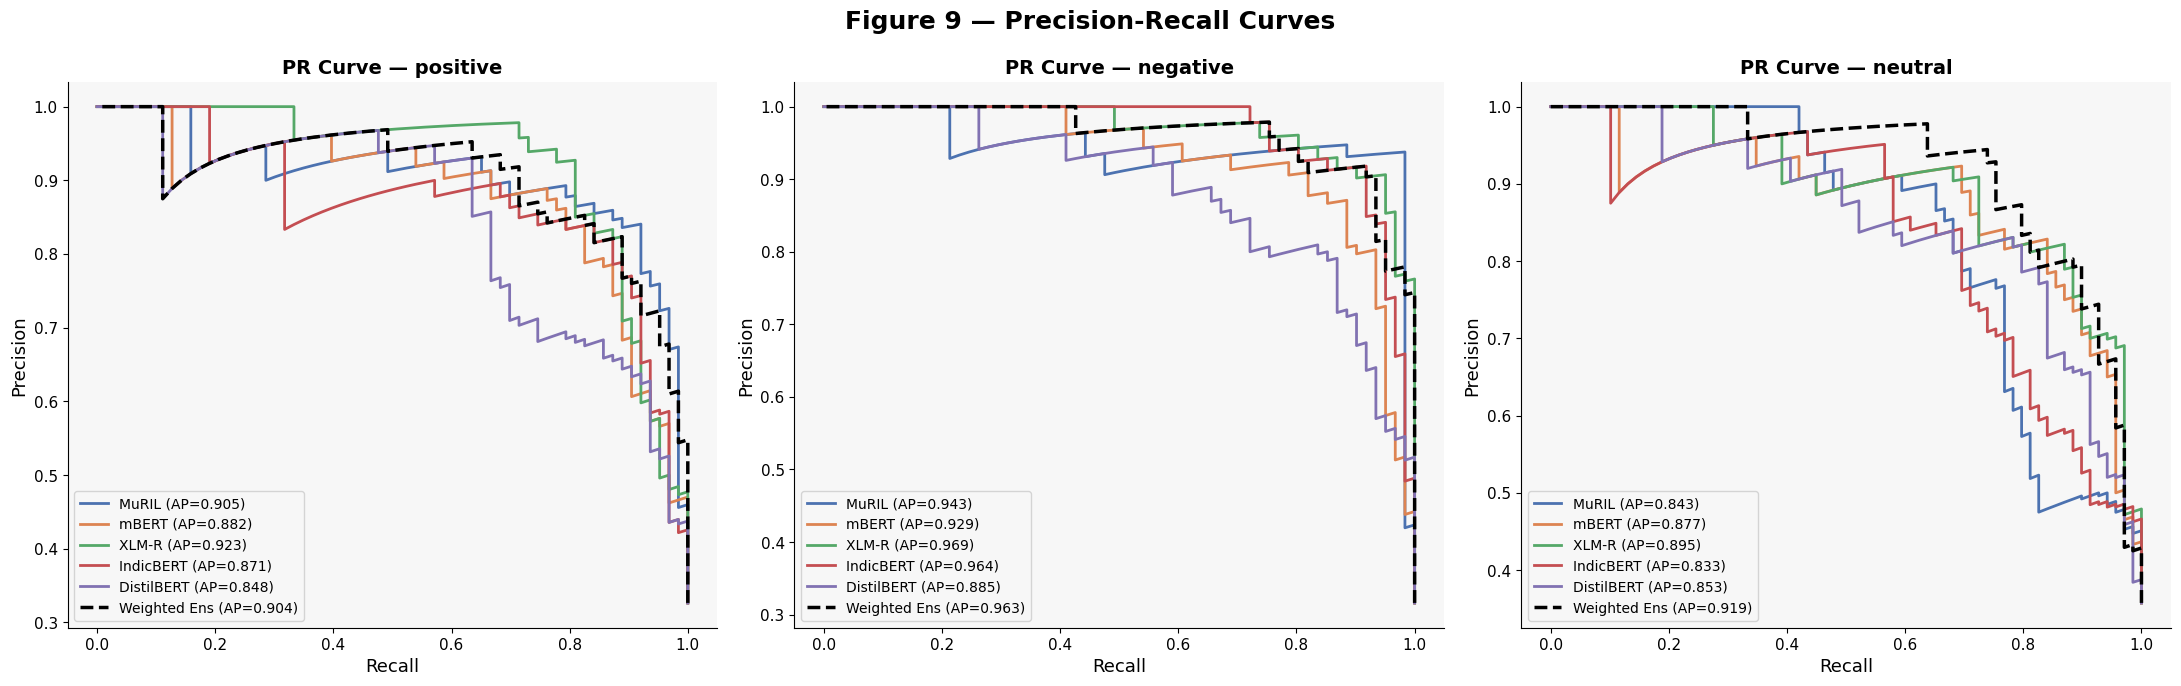

Saved fig9_pr_curves.png


In [ ]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Figure 9 — Precision-Recall Curves", fontsize=18, fontweight="bold")

for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_names)):
    for i, (name, r) in enumerate(all_res.items()):
        prec, rec, _ = precision_recall_curve(y_bin[:, cls_idx],
                                               r["probs"][:, cls_idx])
        ap = average_precision_score(y_bin[:, cls_idx], r["probs"][:, cls_idx])
        ax.plot(rec, prec, color=COLORS[i], lw=2.0,
                label=f"{r['short_name']} (AP={ap:.3f})")
    prec, rec, _ = precision_recall_curve(y_bin[:, cls_idx],
                                           best_ens["probs"][:, cls_idx])
    ap = average_precision_score(y_bin[:, cls_idx], best_ens["probs"][:, cls_idx])
    ax.plot(rec, prec, "k--", lw=2.5,
            label=f"Weighted Ens (AP={ap:.3f})")
    ax.set_title(f"PR Curve — {cls_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Recall", fontsize=13)
    ax.set_ylabel("Precision", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, loc="lower left")

plt.tight_layout()
plt.savefig(OUT / "fig9_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig9_pr_curves.png")

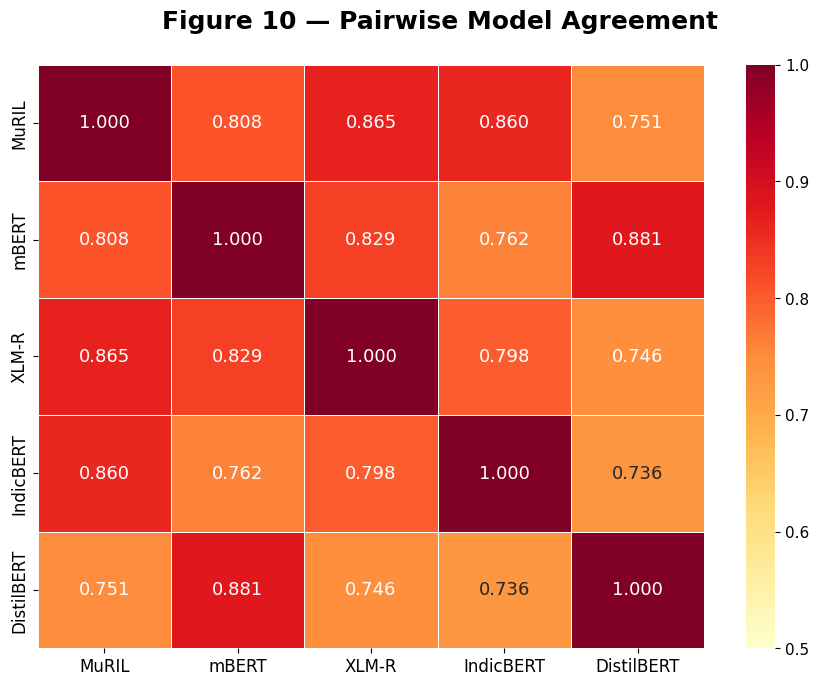

Saved fig10_model_agreement.png


In [ ]:
# Model Agreement Heatmap
n = len(model_names)
agree = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        agree[i, j] = (
            all_res[model_names[i]]["preds"] == all_res[model_names[j]]["preds"]
        ).mean()

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Figure 10 — Pairwise Model Agreement", fontsize=18, fontweight="bold")
sns.heatmap(agree, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=model_names, yticklabels=model_names,
            vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax,
            annot_kws={"size": 13})
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.savefig(OUT / "fig10_model_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig10_model_agreement.png")

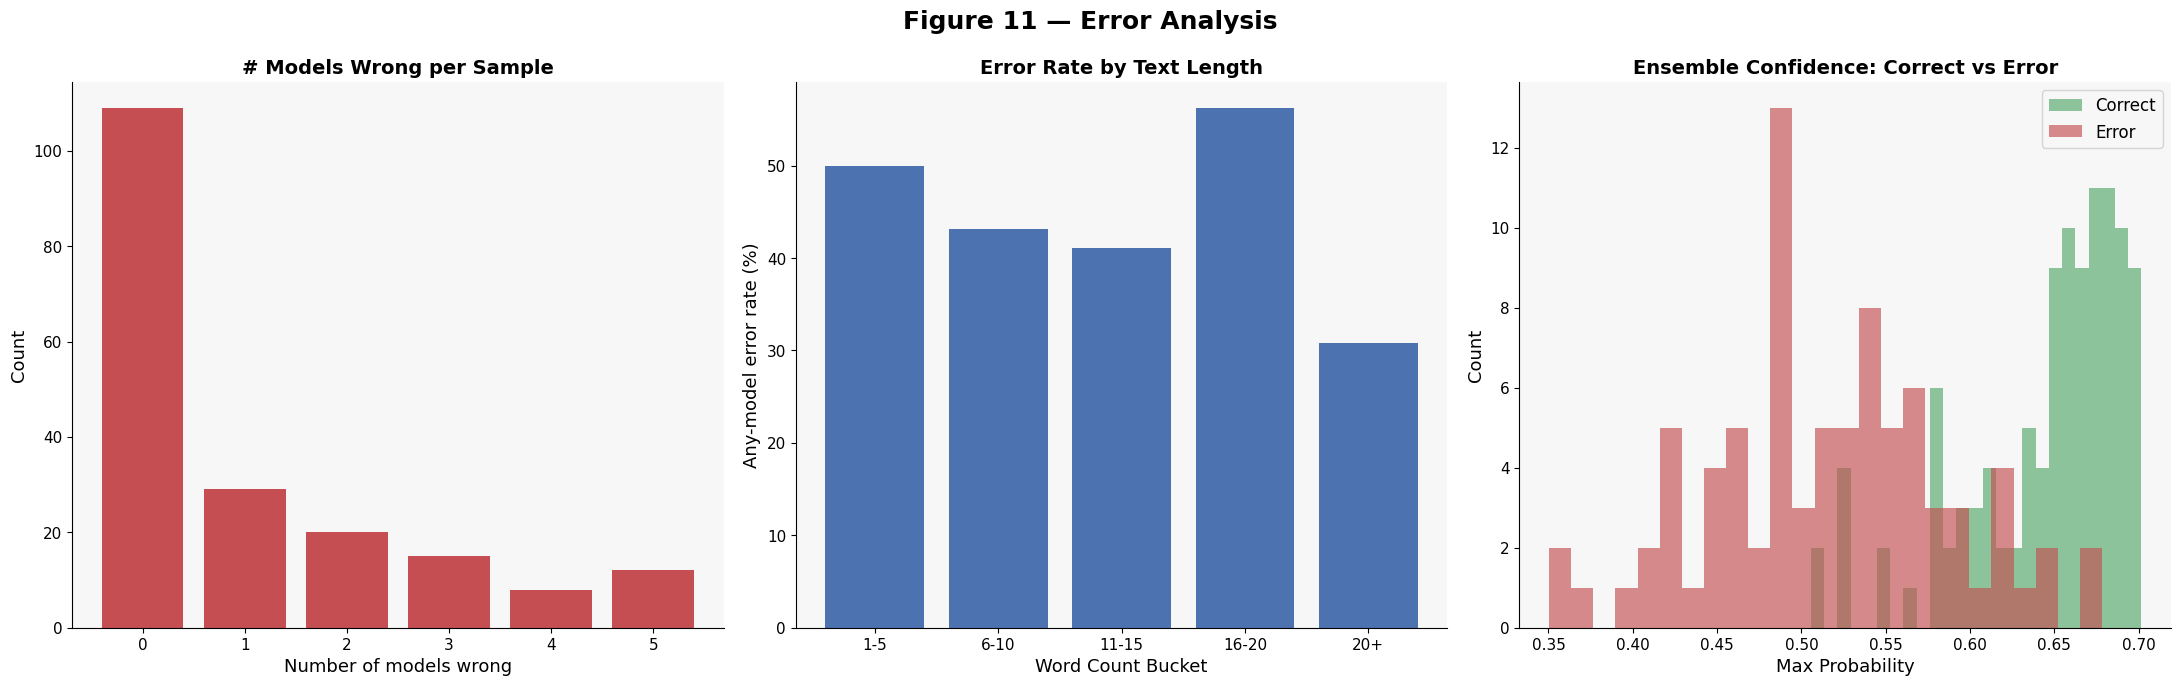

Saved fig11_error_analysis.png


In [ ]:
# Error Analysis
test_df = pd.DataFrame({
    "text"      : X_test,
    "true"      : y_test,
    "words"     : [len(t.split()) for t in X_test],
    "soft_conf" : soft_probs.max(axis=1),
})
for name, r in all_res.items():
    test_df[f"pred_{name}"] = r["preds"]

test_df["n_wrong"] = sum(
    (test_df[f"pred_{n}"] != test_df["true"]).astype(int)
    for n in model_names
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Figure 11 — Error Analysis", fontsize=18, fontweight="bold")

wc = test_df["n_wrong"].value_counts().sort_index()
axes[0].bar(wc.index, wc.values, color=COLORS[3], edgecolor="none")
axes[0].set_title("# Models Wrong per Sample", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of models wrong", fontsize=13)
axes[0].set_ylabel("Count", fontsize=13)
axes[0].tick_params(axis="both", labelsize=11)

len_bins = pd.cut(test_df["words"], [0,5,10,15,20,999],
                  labels=["1-5","6-10","11-15","16-20","20+"])
test_df["len_bin"] = len_bins
err_rate = test_df.groupby("len_bin", observed=True)["n_wrong"].apply(
    lambda x: (x > 0).mean() * 100
)
axes[1].bar(err_rate.index, err_rate.values, color=COLORS[0], edgecolor="none")
axes[1].set_title("Error Rate by Text Length", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Word Count Bucket", fontsize=13)
axes[1].set_ylabel("Any-model error rate (%)", fontsize=13)
axes[1].tick_params(axis="both", labelsize=11)

mask_c = test_df["n_wrong"] == 0
axes[2].hist(test_df.loc[ mask_c, "soft_conf"], bins=25, alpha=0.65,
             label="Correct", color=CLASS_COLORS["positive"])
axes[2].hist(test_df.loc[~mask_c, "soft_conf"], bins=25, alpha=0.65,
             label="Error",   color=CLASS_COLORS["negative"])
axes[2].set_title("Ensemble Confidence: Correct vs Error", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Max Probability", fontsize=13)
axes[2].set_ylabel("Count", fontsize=13)
axes[2].tick_params(axis="both", labelsize=11)
axes[2].legend(fontsize=12)

plt.tight_layout()
plt.savefig(OUT / "fig11_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig11_error_analysis.png")


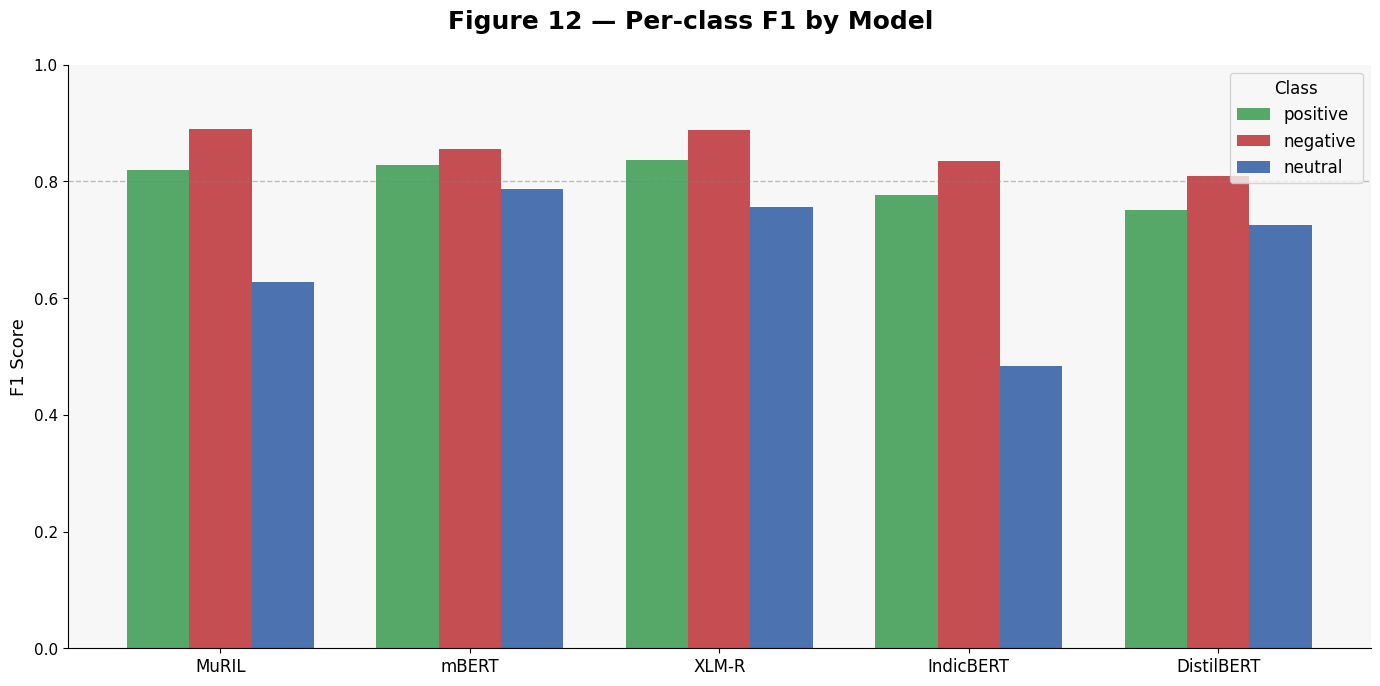

Saved fig12_perclass_f1.png


In [ ]:
# Per-class F1 Breakdown
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Figure 12 — Per-class F1 by Model", fontsize=18, fontweight="bold")

x     = np.arange(len(model_names))
width = 0.25

for i, cls in enumerate(class_names):
    f1_vals = [all_res[m]["report"][cls]["f1-score"] for m in model_names]
    ax.bar(x + i * width, f1_vals, width,
           label=cls, color=CLASS_COLORS[cls], edgecolor="none")

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score", fontsize=13)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Class", fontsize=12, title_fontsize=12)
ax.axhline(0.8, color="gray", ls="--", lw=1, alpha=0.5, label="0.8 threshold")

plt.tight_layout()
plt.savefig(OUT / "fig12_perclass_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig12_perclass_f1.png")

In [ ]:
# Ablation Study
# Training best model (XLM-R) on original English src directly
# Comparing vs training on translated Kannada
# Answers: does translation actually help or hurt?

print("Ablation: training XLM-R on original English (no translation)...")

# split using original English src instead of translated_en
abl_clf = df[["src_clean", "label_id"]].dropna().copy()
abl_clf = abl_clf[abl_clf["src_clean"].str.strip().str.len() > 5]

X_train_abl, X_test_abl, y_train_abl, y_test_abl = train_test_split(
    abl_clf["src_clean"].tolist(),
    abl_clf["label_id"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=abl_clf["label_id"].tolist()
)

# temporarily swap training data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = X_train_abl, X_test_abl, y_train_abl, y_test_abl

abl_res = finetune("xlm-roberta-base", "XLM-R (src)")

# restore original training data
X_train, X_test, y_train, y_test = X_train_orig, X_test_orig, y_train_orig, y_test_orig

print("\n Ablation Results ")
print(f"{'Setup':<30} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print("─" * 58)
print(f"{'XLM-R on translated (kn→en)':<30} "
      f"{all_res['XLM-R']['accuracy']:>8.4f} "
      f"{all_res['XLM-R']['f1']:>8.4f} "
      f"{all_res['XLM-R']['auc_roc']:>8.4f}")
print(f"{'XLM-R on original English':<30} "
      f"{abl_res['accuracy']:>8.4f} "
      f"{abl_res['f1']:>8.4f} "
      f"{abl_res['auc_roc']:>8.4f}")

delta_f1  = all_res["XLM-R"]["f1"] - abl_res["f1"]
delta_acc = all_res["XLM-R"]["accuracy"] - abl_res["accuracy"]
print(f"\nTranslation pipeline advantage:")
print(f"  F1  delta : {delta_f1:+.4f}")
print(f"  Acc delta : {delta_acc:+.4f}")

if delta_f1 > 0:
    print("\n→ Translation HELPS — translated text gives better sentiment classification")
elif delta_f1 < 0:
    print("\n→ Translation HURTS — original English performs better")
else:
    print("\n→ No difference — translation neither helps nor hurts")

Ablation: training XLM-R on original English (no translation)...

──────────────────────────────────────────────────
Training : XLM-R (src)
──────────────────────────────────────────────────


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.088500,0.916586,0.487047,0.382139,0.320683,0.487047
2,0.950100,0.552296,0.787565,0.760711,0.832136,0.787565
3,0.636400,0.427201,0.854922,0.849655,0.873510,0.854922
4,0.445900,0.328199,0.891192,0.889503,0.892532,0.891192


  Acc=0.8912  F1=0.8895  AUC=0.9812

 Ablation Results 
Setup                               Acc       F1      AUC
──────────────────────────────────────────────────────────
XLM-R on translated (kn→en)      0.8290   0.8236   0.9570
XLM-R on original English        0.8912   0.8895   0.9812

Translation pipeline advantage:
  F1  delta : -0.0659
  Acc delta : -0.0622

→ Translation HURTS — original English performs better


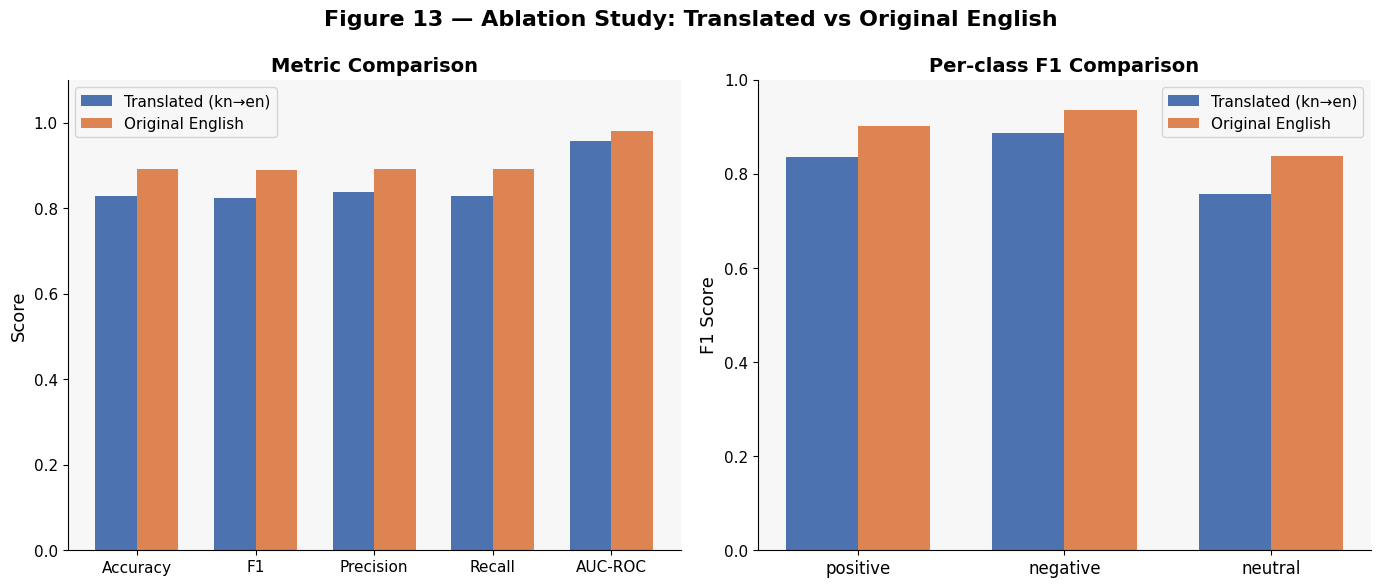

Saved fig13_ablation.png


In [ ]:
# Ablation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 13 — Ablation Study: Translated vs Original English",
             fontsize=16, fontweight="bold")

metrics  = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
tr_vals  = [all_res["XLM-R"]["accuracy"], all_res["XLM-R"]["f1"],
            all_res["XLM-R"]["precision"], all_res["XLM-R"]["recall"],
            all_res["XLM-R"]["auc_roc"]]
src_vals = [abl_res["accuracy"], abl_res["f1"],
            abl_res["precision"], abl_res["recall"],
            abl_res["auc_roc"]]

x     = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, tr_vals,  width, label="Translated (kn→en)",
            color=COLORS[0], edgecolor="none")
axes[0].bar(x + width/2, src_vals, width, label="Original English",
            color=COLORS[1], edgecolor="none")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score", fontsize=13)
axes[0].set_title("Metric Comparison", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)

# per-class F1 comparison
cls_tr  = [all_res["XLM-R"]["report"][c]["f1-score"] for c in class_names]
cls_src = [abl_res["report"][c]["f1-score"] for c in class_names]
x2 = np.arange(len(class_names))
axes[1].bar(x2 - width/2, cls_tr,  width, label="Translated (kn→en)",
            color=COLORS[0], edgecolor="none")
axes[1].bar(x2 + width/2, cls_src, width, label="Original English",
            color=COLORS[1], edgecolor="none")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(class_names, fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("F1 Score", fontsize=13)
axes[1].set_title("Per-class F1 Comparison", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(OUT / "fig13_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig13_ablation.png")

In [ ]:
# Saving CSVs

# full dataset with all features
keep_cols = [
    "src_clean", "tgt_clean", "translated_en", "label_str", "label_id",
    "src_words", "tgt_words", "src_chars", "tgt_chars",
    "len_ratio", "avg_word_len", "ttr",
    "is_short", "is_long",
    "sent_bleu", "rouge1", "rouge2", "rougeL", "bertscore",
]
df[[c for c in keep_cols if c in df.columns]].to_csv(
    OUT / "full_dataset_with_features.csv", index=False
)
print("Saved full_dataset_with_features.csv")

# test set predictions from all models
test_preds_df = pd.DataFrame({
    "text"      : X_test,
    "true_label": [ID2LABEL[y] for y in y_test],
    "true_id"   : y_test,
})
for name, r in all_res.items():
    test_preds_df[f"pred_{name}"]     = [ID2LABEL[p] for p in r["preds"]]
    test_preds_df[f"prob_pos_{name}"] = r["probs"][:, 0]
    test_preds_df[f"prob_neg_{name}"] = r["probs"][:, 1]
    test_preds_df[f"prob_neu_{name}"] = r["probs"][:, 2]

test_preds_df["soft_pred"]     = [ID2LABEL[p] for p in soft_preds]
test_preds_df["hard_pred"]     = [ID2LABEL[p] for p in hard_preds]
test_preds_df["weighted_pred"] = [ID2LABEL[p] for p in weighted_preds]
test_preds_df.to_csv(OUT / "test_predictions.csv", index=False)
print("Saved test_predictions.csv")

# ablation results
abl_df = pd.DataFrame([
    {
        "setup"    : "XLM-R on translated (kn→en)",
        "accuracy" : all_res["XLM-R"]["accuracy"],
        "f1"       : all_res["XLM-R"]["f1"],
        "precision": all_res["XLM-R"]["precision"],
        "recall"   : all_res["XLM-R"]["recall"],
        "auc_roc"  : all_res["XLM-R"]["auc_roc"],
    },
    {
        "setup"    : "XLM-R on original English",
        "accuracy" : abl_res["accuracy"],
        "f1"       : abl_res["f1"],
        "precision": abl_res["precision"],
        "recall"   : abl_res["recall"],
        "auc_roc"  : abl_res["auc_roc"],
    },
])
abl_df.to_csv(OUT / "ablation_results.csv", index=False)
print("Saved ablation_results.csv")

print("\nAll CSVs saved:")
for f in sorted(OUT.iterdir()):
    if f.suffix == ".csv":
        print(f"  {f.name:<45} {f.stat().st_size//1024:>5} KB")

Saved full_dataset_with_features.csv
Saved test_predictions.csv
Saved ablation_results.csv

All CSVs saved:
  ablation_results.csv                              0 KB
  full_dataset_with_features.csv                  430 KB
  results_all_models.csv                            0 KB
  test_predictions.csv                             59 KB


In [ ]:
# Research Summary

best_ind = max(all_res.values(), key=lambda r: r["f1"])
best_ens = max(ens_res.values(), key=lambda r: r["f1"])
mi_f1    = np.mean([v["f1"] for k, v in all_res.items() if k in ["MuRIL","IndicBERT"]])
mg_f1    = np.mean([v["f1"] for k, v in all_res.items() if k in ["mBERT","XLM-R","DistilBERT"]])

print("  RESEARCH SUMMARY")

print(f"""
Dataset
  Total samples     : {len(df)}
  Classes           : positive={Counter(df['label_str'])['positive']}  negative={Counter(df['label_str'])['negative']}  neutral={Counter(df['label_str'])['neutral']}
  Train / Test      : {len(X_train)} / {len(X_test)}

Translation Quality  (IndicTrans2, Kannada → English)
  Corpus BLEU       : {corpus_bleu:.2f}
  ROUGE-1           : {np.mean(r1_scores):.4f}
  ROUGE-L           : {np.mean(rL_scores):.4f}
  BERTScore F1      : {mean_bs:.4f}

Individual Model Results
  Best model        : {best_ind['short_name']}  F1={best_ind['f1']:.4f}  AUC={best_ind['auc_roc']:.4f}
  Worst model       : {min(all_res.values(), key=lambda r: r['f1'])['short_name']}  F1={min(all_res.values(), key=lambda r: r['f1'])['f1']:.4f}

Ensemble Results
  Best ensemble     : {best_ens['short_name']}  F1={best_ens['f1']:.4f}  AUC={best_ens['auc_roc']:.4f}
  vs best model     : {best_ens['f1'] - best_ind['f1']:+.4f} F1

Indic-specific vs General Multilingual
  Indic  (MuRIL + IndicBERT) mean F1      : {mi_f1:.4f}
  General (mBERT + XLM-R + DistilBERT)   : {mg_f1:.4f}
  Winner            : {'Indic-specific' if mi_f1 > mg_f1 else 'General multilingual'}

Ablation Study  (XLM-R only)
  Translated kn→en  : F1={all_res['XLM-R']['f1']:.4f}
  Original English  : F1={abl_res['f1']:.4f}
  Translation cost  : {all_res['XLM-R']['f1'] - abl_res['f1']:+.4f} F1
  Interpretation    : Translation introduces ~{abs(all_res['XLM-R']['f1'] - abl_res['f1'])*100:.1f} pp degradation
                      Pipeline still viable for Kannada-only input
""")

print(" Full Rankings ")
print(results_df[["Model","Accuracy","F1","AUC-ROC","MCC","Kappa"]].to_string(index=False))

print(f"\n Per-class F1  ({best_ind['short_name']})")
rep = best_ind["report"]
for cls in ["positive", "negative", "neutral"]:
    print(f"  {cls:<10}  precision={rep[cls]['precision']:.3f}  "
          f"recall={rep[cls]['recall']:.3f}  f1={rep[cls]['f1-score']:.3f}")

print("\n Output Files ")
for f in sorted(OUT.iterdir()):
    if f.is_file():
        print(f"  {f.name:<48} {f.stat().st_size//1024:>5} KB")



  RESEARCH SUMMARY

Dataset
  Total samples     : 962
  Classes           : positive=316  negative=302  neutral=344
  Train / Test      : 769 / 193

Translation Quality  (IndicTrans2, Kannada → English)
  Corpus BLEU       : 32.61
  ROUGE-1           : 0.6488
  ROUGE-L           : 0.6071
  BERTScore F1      : 0.9548

Individual Model Results
  Best model        : XLM-R  F1=0.8236  AUC=0.9570
  Worst model       : IndicBERT  F1=0.6903

Ensemble Results
  Best ensemble     : Soft Voting  F1=0.8304  AUC=0.9596
  vs best model     : +0.0068 F1

Indic-specific vs General Multilingual
  Indic  (MuRIL + IndicBERT) mean F1      : 0.7314
  General (mBERT + XLM-R + DistilBERT)   : 0.8016
  Winner            : General multilingual

Ablation Study  (XLM-R only)
  Translated kn→en  : F1=0.8236
  Original English  : F1=0.8895
  Translation cost  : -0.0659 F1
  Interpretation    : Translation introduces ~6.6 pp degradation
                      Pipeline still viable for Kannada-only input

 Full Rank